In [3]:
%autoreload 2

In [2]:
%reload_ext autoreload

import numpy as np
import pandas as pd

import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from datetime import datetime as dt, timedelta
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10})

__BOUT FINDER__

In [4]:
path = fr'C:\Data\Imaging\260425_overlap\fish11_2//'
fish = Gafftopsail(path, sequence  = 1, filelist = ['stimulus', 'tail', 'eye'])

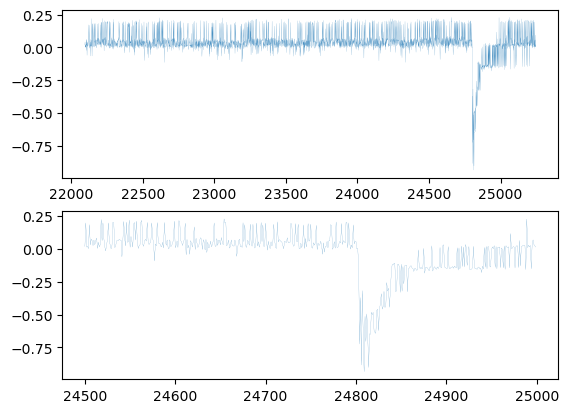

In [13]:
fig ,ax = plt.subplots(2, 1)
time =fish.stimulus_df[fish.stimulus_df.stim_name == str('dot_l')].real_starttime_s.iloc[0]
ax[0].plot(fish.tail_df[fish.tail_df.real_time_s.between(time, time + 35)].tail_sum, linewidth = .1)
ax[1].plot(fish.tail_df[24500:25000].tail_sum, linewidth = .1)#
plt.show()
plt.close()
#[24780, 24900]


In [14]:
fig = bhfd.tail_finder(fish, time_window_s=.1, std_scale =3, startframe = 100000, endframe = 110000)
fish.bout_df.to_csv(fish.path + '//Tail//tail_bout_df.csv')
plt.savefig(fish.path + '//Graphs//bout_example.png')

2p: neg/pos = L/R
 behavior: neg/pos = R/L
aadding bouts


C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:383: RuntimeWarning: Mean of empty slice
  tail_angle_neg[i] = np.nanmean(neg[cont_tuples[i][0]:cont_tuples[i][1]])
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:384: RuntimeWarning: All-NaN slice encountered
  tail_angle_negmin[i] = np.nanmin(neg[cont_tuples[i][0]:cont_tuples[i][1]])
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:381: RuntimeWarning: Mean of empty slice
  tail_angle_pos[i] = np.nanmean(pos[cont_tuples[i][0]:cont_tuples[i][1]])
C:\Users\Zichen\anaconda3\envs\2ptank\Lib\site-packages\2ptank\behavior_finder.py:382: RuntimeWarning: All-NaN slice encountered
  tail_angle_posmax[i] = np.nanmax(pos[cont_tuples[i][0]:cont_tuples[i][1]])


__WHERE / WHEN IS MY BOUT__

In [6]:
stim_lists =  [['dot_l', 'dot_r'],
                        ['forward', 'left', 'right', 'backward'],
               ["['dot_l', 'forward']", "['dot_r', 'forward']",
                         "['dot_l', 'left']", "['dot_r', 'left']",
                        "['dot_l', 'right']", "['dot_r', 'right']",
                       "['dot_l', 'backward']", "['dot_r', 'backward']"]]
# stim_lists = [['forward_0', 'left_0', 'right_0', 'backward_0'],
#                         ['forward_1', 'left_1', 'right_1', 'backward_1'],
#                         ['forward_2', 'left_2', 'right_2', 'backward_2'],
#                         ['forward_3', 'left_3', 'right_3', 'backward_3']]
#stim_matrix = np.array([['dot_l_aaa', 'dot_r_aaa', 'dot_l_aab', 'dot_r_aab', 'dot_l_aba',

In [16]:

fig = bhfd.plot_boutangle_distribution(fish, stim_lists = stim_lists)
plt.savefig(fish.path + "Graphs//bout_stats.png")
plt.close(fig)
fig = bhfd.plot_bouttime_distribution(fish, stim_lists = stim_lists)
plt.savefig(fish.path + "Graphs//bouttime_stats.png")
plt.close(fig)

AttributeError: 'DataFrame' object has no attribute 'nearest_saccade_conv'

In [17]:
stim_matrix =  np.array([['skip', 'dot_l', 'dot_r'],
                        ['forward', "['dot_l', 'forward']", "['dot_r', 'forward']"],
                        ['left', "['dot_l', 'left']", "['dot_r', 'left']"],
                        ['right', "['dot_l', 'right']", "['dot_r', 'right']"],
                        ['backward', "['dot_l', 'backward']", "['dot_r', 'backward']"]])
fig = bhfd.plot_all_tails(fish, stim_matrix)
plt.savefig(fish.path + "//Graphs//bout_all.png")
plt.close()

__Across Fish__

In [ ]:

for f in ['3', '4', '5', '6', '1', '2']:
    path = f'Z://cleo//Imaging//260411_gratingvelocity//fish{f}//'
    fish = Gafftopsail(path, sequence=5, filelist=['stimulus', 'tail', 'eye'])
    #fish = Coelacanth(path, filelist=['taileye', 'stimulus'])
    if type(fish) == Gafftopsail:
        pass
    elif type(fish) == Coelacanth:
        fish.taileye_df.columns = ['f0_x', 'f0_vx', 'f0_y', 'f0_vy', 'tail_sum', 'f0_vtheta',
                               'f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
                               'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
                               'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11',
                               'f0_pos_x_e0', 'f0_pos_y_e0', 'f0_dim_x_e0', 'f0_dim_y_e0', 'th_e0',
                               'f0_pos_x_e1', 'f0_pos_y_e1', 'f0_dim_x_e1', 'f0_dim_y_e1', 'th_e1',
                               'biggest_area', 't', 'real_time', 'real_time_s']
        cols = ['f0_theta_00', 'f0_theta_01', 'f0_theta_02', 'f0_theta_03',
                               'f0_theta_04', 'f0_theta_05', 'f0_theta_06', 'f0_theta_07',
                               'f0_theta_08', 'f0_theta_09', 'f0_theta_10', 'f0_theta_11']
        fish.taileye_df.loc[:, 'tail_sum'] = fish.taileye_df[cols].sum(axis = 1)
        fish.tail_df = fish.taileye_df
        fish.eye_df = fish.taileye_df
    fig = bhfd.tail_finder(fish, time_window_s=.1, std_scale=3, startframe=20000, endframe=40000)
    fish.bout_df.to_csv(fish.path + '//Tail//tail_bout_df.csv')
    #for overlap fishes
    # omr_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
    # dot_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
    # overlap_stim = [i for i in fish.stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
    # stimlists = [omr_stim, dot_stim, overlap_stim]
    #for dot fish
    # stimlists = [['dot_l_3', 'dot_r_3'],['dot_l_5', 'dot_r_5'],['dot_l_10', 'dot_r_10'], ['dot_l_20', 'dot_r_20'],['dot_l_40', 'dot_r_40']]
    plt.savefig(fish.path + '//Graphs//bout_example.png')
    fig = bhfd.plot_boutangle_distribution(fish, stim_lists)
    plt.savefig(fish.path + "Graphs//bout_stats.png")
    plt.close(fig)
    fig = bhfd.plot_bouttime_distribution(fish, stim_lists)
    plt.savefig(fish.path + "Graphs//bouttime_stats.png")
    plt.close(fig)

    fig = bhfd.plot_all_tails(fish, stim_matrix)
    plt.savefig(path + "//Graphs//bout_all.png")
    plt.close(fig)

In [7]:
fish.stimulus_df.stim_name.unique()

array(['forward_3', 'left_0', 'left_1', 'forward_2', 'backward_0',
       'left_3', 'left_2', 'forward_0', 'right_0', 'forward_1', 'right_1',
       'right_3', 'backward_1', 'backward_2', 'backward_3', 'right_2'],
      dtype=object)